# Credit Risk & Loan Default Prediction
## Phase 3 — Feature Engineering & Train/Test Split

**Goal of this notebook.** Get the data ready for modeling, in a way that gives an *honest* estimate of how the model would perform on borrowers it has never seen. That takes three steps:

1. **Split** the borrowers into a training set (80%) and a test set (20%) *before* anything else is learned from the data.
2. **Clean** using the Phase 1 rules, but learn every median and cap from the training set only.
3. **Add three new features** that summarize what Phase 2 showed us.

**Why the order matters (the key idea of this phase).** Think of the test set as a final exam. If a student sees the exam questions while studying, a high score means nothing. In modeling this is called **data leakage**: any information from the test borrowers seeping into training. In Phase 1 we computed medians and caps on all 150,000 borrowers, including the ones that will become the test set. The effect was small, but it is a standard concern in modeling, so now we redo it properly: the cleaning rules are the same, but the numbers they use are learned from the training set alone and then applied unchanged to the test set.

In [1]:
import sys
sys.path.insert(0, "..")            # so we can import from the src/ folder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from src.preprocessing import CreditCleaner, add_features, TARGET, PAST_DUE_COLS, UTIL

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Load the raw data and remove the one impossible row

Reading the raw file again (not the Phase 1 cleaned file), because the cleaning must now happen *after* the split. The one borrower with age 0 is removed first. That's a fixed rule that uses no statistics from the data, so it can't leak anything.

In [2]:
raw = pd.read_csv("../data/cs-training.csv", index_col=0)
print(f"Raw rows: {len(raw):,}")
raw = raw[raw.age >= 18]
print(f"After dropping impossible ages: {len(raw):,}")

Raw rows: 150,000
After dropping impossible ages: 149,999


## 2. Stratified train/test split (80% / 20%)

- **Train (80%)**: the data the model learns from, and the only data used to learn cleaning values.
- **Test (20%)**: locked away until the final evaluation in Phase 5. We won't look at it while building models.

**Stratified** means the split keeps the same default rate (about 6.7%) in both parts. With only about 1 in 15 borrowers defaulting, a purely random split could by chance put noticeably more or fewer defaulters in one part; stratifying prevents that.

**`random_state=42`** just fixes the shuffle so the split is identical every time the notebook runs. That makes the results reproducible. (The number 42 has no special meaning.)

In [3]:
X = raw.drop(columns=TARGET)
y = raw[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

split_summary = pd.DataFrame({
    "borrowers": [len(y_train), len(y_test)],
    "defaulters": [int(y_train.sum()), int(y_test.sum())],
    "default rate": [f"{y_train.mean():.3%}", f"{y_test.mean():.3%}"],
}, index=["Train (80%)", "Test (20%)"])
split_summary

,borrowers,defaulters,default rate
Train (80%),119999,8021,6.684%
Test (20%),30000,2005,6.683%


Both sets have essentially the same default rate, so the test set is a fair miniature of the whole. The test set has about 2,000 defaulters, enough to measure performance reliably.

## 3. Cleaning, learned from the training set only

`CreditCleaner` (in `src/preprocessing.py`) applies the same rules as Phase 1. It has two steps, just like a student:

- **`fit`**: study the *training* data and record the numbers needed: the median debt ratio, the income cap, the median income for each age band, and so on.
- **`transform`**: apply those recorded numbers to any dataset.

We `fit` on training data only, then `transform` both training and test.

In [4]:
cleaner = CreditCleaner()
cleaner.fit(X_train)

learned = pd.Series({
    "Median DebtRatio of reliable rows": round(cleaner.debt_ratio_fill_, 4),
    "Income cap (99.9th percentile)": round(cleaner.income_cap_, 0),
    "Fill value for dependents": cleaner.dependents_fill_,
    "Largest genuine count, 30-59d late": cleaner.past_due_max_[PAST_DUE_COLS[0]],
    "Largest genuine count, 60-89d late": cleaner.past_due_max_[PAST_DUE_COLS[1]],
    "Largest genuine count, 90+d late": cleaner.past_due_max_[PAST_DUE_COLS[2]],
})
print("Values learned from the TRAINING set:")
print(learned.to_string())
print()
print("Median monthly income by age band (used to fill missing income):")
print(cleaner.income_by_age_.round(0).to_string())

Values learned from the TRAINING set:
Median DebtRatio of reliable rows         0.2909
Income cap (99.9th percentile)        77248.0000
Fill value for dependents                 0.0000
Largest genuine count, 30-59d late       13.0000
Largest genuine count, 60-89d late       11.0000
Largest genuine count, 90+d late         17.0000

Median monthly income by age band (used to fill missing income):
age
18-29    2550.0
30-39    4678.0
40-49    6000.0
50-59    6352.0
60-69    5906.0
70+      4522.0


In [5]:
train_clean = cleaner.transform(X_train)
test_clean = cleaner.transform(X_test)

print("Missing values left  -> train:", int(train_clean.isna().sum().sum()), "| test:", int(test_clean.isna().sum().sum()))

Missing values left  -> train: 0 | test: 0


### Check 1: how much did the leakage in Phase 1 actually matter?

Compare the numbers Phase 1 used (learned from all 150,000 borrowers) with the ones learned now from training only.

In [6]:
leaky = CreditCleaner().fit(X)   # what Phase 1 effectively did: learn from everything
compare = pd.DataFrame({
    "Phase 1 (all data)": [leaky.debt_ratio_fill_, leaky.income_cap_, *leaky.income_by_age_.values],
    "Phase 3 (train only)": [cleaner.debt_ratio_fill_, cleaner.income_cap_, *cleaner.income_by_age_.values],
}, index=["Median DebtRatio", "Income cap", *[f"Median income, age {b}" for b in leaky.income_by_age_.index]])
compare["% difference"] = ((compare["Phase 3 (train only)"] / compare["Phase 1 (all data)"] - 1) * 100).round(2)
compare.round(3)

,Phase 1 (all data),Phase 3 (train only),% difference
Median DebtRatio,0.290,0.291,0.26
Income cap,78396.137,77248.000,-1.46
"Median income, age 18-29",2557.000,2550.000,-0.27
"Median income, age 30-39",4666.000,4677.500,0.25
"Median income, age 40-49",6000.000,6000.000,0.00
"Median income, age 50-59",6333.000,6352.500,0.31
"Median income, age 60-69",5918.500,5906.000,-0.21
"Median income, age 70+",4550.000,4522.000,-0.62


**What this shows.** Every learned number moved by less than 1.5% (the income cap moved the most), so the Phase 1 shortcut would have changed results very little. The pipeline version still guarantees that no test-set information influenced the cleaning.

### Check 2: does the new code reproduce Phase 1?

If we let the cleaner learn from all the data, it should produce exactly the Phase 1 cleaned file. This confirms we moved the rules into code without accidentally changing them.

In [7]:
phase1 = pd.read_csv("../data/cs-training-clean.csv", index_col=0)
rebuilt = CreditCleaner().fit(X).transform(X)
rebuilt.insert(0, TARGET, y)
rebuilt.index.name = phase1.index.name
pd.testing.assert_frame_equal(rebuilt[phase1.columns], phase1, check_dtype=False, check_exact=False, rtol=1e-9)
print("Match: the reusable code reproduces the Phase 1 cleaned dataset exactly.")

Match: the reusable code reproduces the Phase 1 cleaned dataset exactly.


## 4. Feature engineering: three new columns

A **feature** is one input column for the model. **Feature engineering** means building new columns from existing ones that make the important patterns easier for a model to use. Phase 2 pointed to three:

| New feature | Definition | Why (from Phase 2) |
|---|---|---|
| `total_late_payments` | 30-59d late + 60-89d late + 90+d late | The three late-payment columns overlap. One combined count captures overall payment history. |
| `ever_late` | 1 if `total_late_payments` > 0, else 0 | The biggest jump in risk was between never late (2.7% default) and late at least once (22%). |
| Utilization bands | 4 yes/no columns: 25-50%, 50-75%, 75-100%, over limit (0-25% is the reference) | Risk climbed in steps with utilization, not in a perfectly straight line. |

**One-hot encoding.** The utilization bands are turned into separate 0/1 columns ("is this borrower in the 50-75% band?"). This lets a simple model like logistic regression give each band its own risk level. We drop the 0-25% column because if all four columns are 0, the borrower must be in that band. A fifth column would carry no new information.

These features use fixed rules (a sum, a comparison, fixed band edges), so they learn nothing from the data and cannot leak. We add them to both sets in the same way.

In [8]:
train_fe = add_features(train_clean)
test_fe = add_features(test_clean)

new_cols = [c for c in train_fe.columns if c not in train_clean.columns]
print("New columns:", new_cols)
print(f"Feature count: {train_clean.shape[1]} -> {train_fe.shape[1]}")

New columns: ['total_late_payments', 'ever_late', 'util_25_50', 'util_50_75', 'util_75_100', 'util_over_limit']
Feature count: 14 -> 20


### Do the new features carry the signal we expect? (training set only)

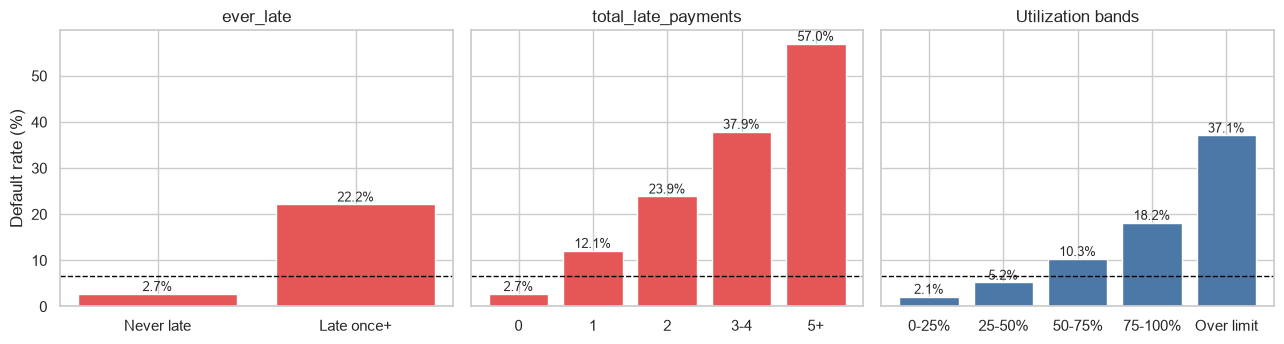

In [9]:
tmp = train_fe.copy()
tmp[TARGET] = y_train

late_band = pd.cut(tmp.total_late_payments, [-1, 0, 1, 2, 4, 1000], labels=["0", "1", "2", "3-4", "5+"])
util_band = pd.from_dummies(
    tmp[["util_25_50", "util_50_75", "util_75_100", "util_over_limit"]], default_category="util_0_25"
)[""].map({"util_0_25": "0-25%", "util_25_50": "25-50%", "util_50_75": "50-75%",
           "util_75_100": "75-100%", "util_over_limit": "Over limit"})
util_band = pd.Categorical(util_band, ["0-25%", "25-50%", "50-75%", "75-100%", "Over limit"], ordered=True)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
overall = y_train.mean() * 100
panels = [
    (tmp.groupby("ever_late")[TARGET].mean().rename({0: "Never late", 1: "Late once+"}), "ever_late", "#E45756"),
    (tmp.groupby(late_band, observed=True)[TARGET].mean(), "total_late_payments", "#E45756"),
    (tmp.groupby(util_band, observed=True)[TARGET].mean(), "Utilization bands", "#4C78A8"),
]
for ax, (s, title, color) in zip(axes, panels):
    ax.bar(s.index.astype(str), s.values * 100, color=color)
    ax.axhline(overall, color="black", ls="--", lw=1)
    for i, v in enumerate(s.values):
        ax.text(i, v * 100 + 0.6, f"{v*100:.1f}%", ha="center", fontsize=9)
    ax.set_title(title)
axes[0].set_ylabel("Default rate (%)")
plt.tight_layout()
plt.savefig("../reports/03_engineered_features.png", dpi=150)
plt.show()

The new features separate risky from safe borrowers cleanly and in the expected direction, which is what we wanted. Nothing here is a surprise, since these are re-packagings of what Phase 2 found. That's the point: each feature has a one-sentence justification.

## 5. What about scaling?

Another common step is scaling. **Scaling** puts columns on comparable ranges (for example, income is in thousands but utilization is around 0 to 2). Logistic regression works better when columns are on similar scales; tree-based models (random forest, XGBoost) do not care at all.

We are *not* scaling here. Scaling also learns numbers from the data (each column's average and spread), so it is another step that must be fit on the training set only. In Phase 4 we'll put scaling inside the logistic regression's own pipeline, so it is automatically learned from the training data and never touches the test set.

## 6. Save the modeling datasets

In [10]:
train_out = train_fe.assign(**{TARGET: y_train})
test_out = test_fe.assign(**{TARGET: y_test})
train_out.to_csv("../data/train.csv", index_label="borrower_id")
test_out.to_csv("../data/test.csv", index_label="borrower_id")
print(f"train.csv: {train_out.shape[0]:,} rows x {train_out.shape[1]} columns")
print(f"test.csv:  {test_out.shape[0]:,} rows x {test_out.shape[1]} columns")
print()
print("Columns:", list(train_out.columns))

train.csv: 119,999 rows x 21 columns
test.csv:  30,000 rows x 21 columns

Columns: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'past_due_code_flag', 'debt_ratio_unreliable_flag', 'income_missing_flag', 'dependents_missing_flag', 'total_late_payments', 'ever_late', 'util_25_50', 'util_50_75', 'util_75_100', 'util_over_limit', 'SeriousDlqin2yrs']


## Phase 3 summary (plain English)

- Split the borrowers **80/20**, keeping the default rate at about 6.7% in both parts. The test set is locked away until Phase 5.
- Moved the Phase 1 cleaning rules into reusable code and re-learned every median and cap from the **training data only**. We checked that this changed the numbers only slightly, and that with all data it exactly reproduces Phase 1.
- Added **three feature groups**: total late payments, an "ever late" flag, and utilization bands.
- Left scaling for Phase 4, where it will be learned inside the model pipeline.